In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'Sukuna.jpg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(194, 259, 3)

In [3]:
h, w = img.shape[:2]
A_true = np.array([[0.8, 0.3, 20], [0.15, 0.7, 10]], dtype=np.float64)
glitched = cv2.warpAffine(img, A_true, (300, 200))

landmarks = np.array([[60, 50], [200, 60], [120, 150]], dtype=np.float64)
glitched_pts = np.round(landmarks @ A_true[:, :2].T + A_true[:, 2])
glitched_pts

array([[ 83.,  54.],
       [198.,  82.],
       [161., 133.]])

In [4]:
P = np.hstack([glitched_pts, np.ones((3, 1))])

abc = np.linalg.solve(P, landmarks[:, 0])
def_ = np.linalg.solve(P, landmarks[:, 1])
M = np.array([abc, def_])

fixed = cv2.warpAffine(glitched, M, (w, h))

print(np.round(M, 3))
print('cv2.getAffineTransform:')
print(np.round(cv2.getAffineTransform(np.float32(glitched_pts), np.float32(landmarks)), 3))

[[  1.359  -0.583 -21.359]
 [ -0.291   1.553  -9.709]]
cv2.getAffineTransform:
[[  1.359  -0.583 -21.359]
 [ -0.291   1.553  -9.709]]


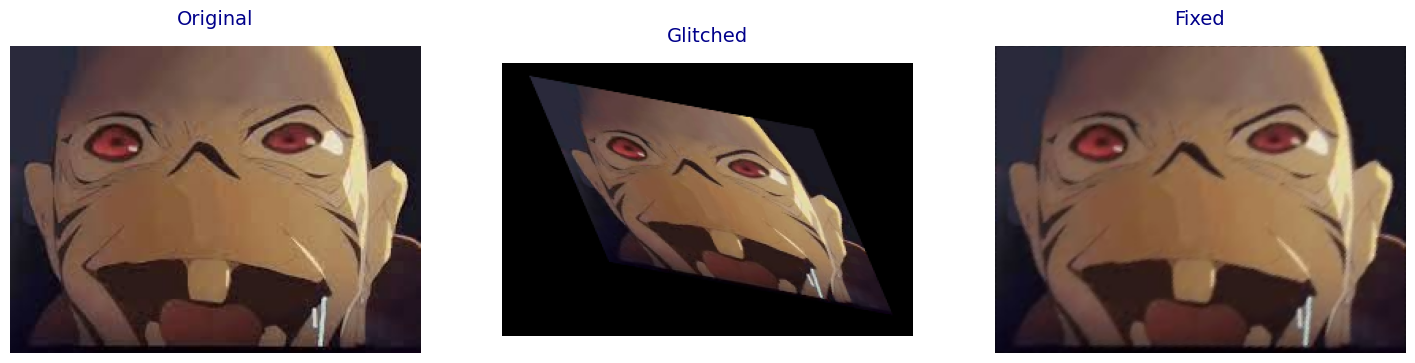

In [5]:
panels = [('Original', img), ('Glitched', glitched), ('Fixed', fixed)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [6]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task7_affine.png', cv2.cvtColor(fixed, cv2.COLOR_RGB2BGR))

True

Each point gives two equations, x' = a*x + b*y + c and y' = d*x + e*y + f. Three points give 6 equations for the 6 unknowns. The x' equations only have a, b, c and the y' ones only d, e, f so it splits into two 3x3 systems with the same matrix [[x, y, 1], ...], solved with np.linalg.solve.

The points can't be on one line otherwise the matrix is singular and has no solution. Result matches cv2.getAffineTransform. It is slightly off from the exact inverse of the glitch because the glitched coordinates were rounded to whole pixels.